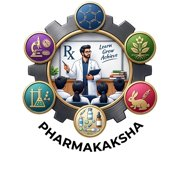

# BP604T · Unit II — AI in Medicinal and Pharmaceutical Chemistry
**Pharmakaksha · Learn · Grow · Achieve**
*AI applications in Pharmaceutical Sciences · B.Pharm Semester VI · PCI NEP 2020*

This notebook contains every example and demo from the Unit II study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit2_AI_in_Medicinal_Chemistry.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP604T_Unit2_AI_in_Medicinal_Chemistry.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. Real drug names and structures are used only to show how the methods work. The models are for learning AI methods only. They are not quality-control, regulatory or clinical tools.

## 2.1 Molecular descriptors
A molecule is written as a **SMILES** string (e.g. paracetamol = `CC(=O)Nc1ccc(O)cc1`). Software turns the structure into **descriptors**, numbers that a model can learn from:

| Descriptor | Meaning | Why it matters |
|---|---|---|
| MW | molecular weight (g/mol) | size; absorption and permeability |
| logP | octanol/water partition (lipophilicity) | membrane permeation, solubility, binding |
| HBD / HBA | hydrogen-bond donors / acceptors | solubility, permeability |
| TPSA | topological polar surface area (Å²) | absorption, brain penetration |
| Rotatable bonds | flexibility | oral bioavailability |

The next cell computes them with **RDKit**, the free cheminformatics library. If RDKit cannot be installed, the cell reads the same values from `drug_descriptors.csv`.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP604T%20AI%20applications%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
    HAVE_RDKIT = True
except ImportError:
    try:
        %pip install -q rdkit
        from rdkit import Chem
        from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
        HAVE_RDKIT = True
    except Exception:
        HAVE_RDKIT = False
print("RDKit available:", HAVE_RDKIT)

In [ ]:
smi = load("drug_smiles.csv")
if HAVE_RDKIT:
    rows = []
    for name, cls, s in smi.itertuples(index=False):
        m = Chem.MolFromSmiles(s)
        rows.append({"drug": name, "drug_class": cls,
                     "MW": round(Descriptors.MolWt(m), 1),
                     "logP": round(Crippen.MolLogP(m), 2),          # calculated (Crippen) logP
                     "HBD": Lipinski.NumHDonors(m), "HBA": Lipinski.NumHAcceptors(m),
                     "TPSA": round(rdMolDescriptors.CalcTPSA(m), 1),
                     "rot_bonds": Lipinski.NumRotatableBonds(m)})
    desc = pd.DataFrame(rows)
else:
    desc = load("drug_descriptors.csv")
desc.head(8)

In [ ]:
# Lipinski's rule of five: MW ≤ 500, logP ≤ 5, HBD ≤ 5, HBA ≤ 10 (one violation is allowed)
desc["ro5_violations"] = ((desc["MW"] > 500).astype(int) + (desc["logP"] > 5).astype(int)
                          + (desc["HBD"] > 5).astype(int) + (desc["HBA"] > 10).astype(int))
# Veber: rotatable bonds ≤ 10 and TPSA ≤ 140 Å²
desc["veber_ok"] = (desc["rot_bonds"] <= 10) & (desc["TPSA"] <= 140)
print(desc.loc[desc["ro5_violations"] > 0, ["drug", "MW", "logP", "HBD", "HBA", "ro5_violations"]])
print("Drugs failing Veber:", desc.loc[~desc["veber_ok"], "drug"].tolist())

In [ ]:
plt.figure(figsize=(8, 5))
plt.axvspan(0, 500, ymin=0, ymax=1, color="#DFF3EC", alpha=0.6)
plt.scatter(desc["MW"], desc["logP"], color="#17725C", s=40)
for _, r in desc.iterrows():
    plt.annotate(r["drug"], (r["MW"], r["logP"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
plt.axhline(5, color="#E07A2E", linestyle="--"); plt.axvline(500, color="#E07A2E", linestyle="--")
plt.xlabel("Molecular weight (g/mol)"); plt.ylabel("Calculated logP")
plt.title("26 marketed drugs in descriptor space (dashed lines: rule-of-five limits)")
plt.grid(alpha=0.3); plt.show()

## 2.2 QSAR: quantitative structure–activity relationships
A QSAR model links descriptors to biological activity. Activity is written as **pIC₅₀ = −log₁₀(IC₅₀ in mol/L)**, so a higher pIC₅₀ means a more potent compound (IC₅₀ 1 µM → pIC₅₀ 6).

`qsar_series.csv` holds 48 fictional analogues from one chemical series, with Hansch-type descriptors: logP, the Hammett constant σ (electronic effect of the substituent), molar refractivity MR (size) and HBD.

In [ ]:
q = load("qsar_series.csv")
print(q.shape)
print(q.drop(columns="compound").corr()["pIC50"].round(2))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_absolute_error

cv = KFold(5, shuffle=True, random_state=1)
X1 = q[["logP", "sigma", "MR", "HBD"]]
q["logP2"] = q["logP"] ** 2                                # Hansch's parabola: activity peaks at an optimum logP
X2 = q[["logP", "logP2", "sigma", "MR", "HBD"]]
for name, X in [("Linear in logP", X1), ("With logP² term", X2)]:
    m = LinearRegression().fit(X, q["pIC50"])
    q2 = r2_score(q["pIC50"], cross_val_predict(LinearRegression(), X, q["pIC50"], cv=cv))
    print(f"{name:15s}  R² = {m.score(X, q['pIC50']):.2f}   Q² (5-fold CV) = {q2:.2f}")

In [ ]:
qsar = LinearRegression().fit(X2, q["pIC50"])
coef = pd.Series(qsar.coef_, index=X2.columns).round(3)
print("pIC50 =", round(qsar.intercept_, 2), "+", " + ".join(f"({v})·{k}" for k, v in coef.items()))
print("Optimum logP =", round(-coef["logP"] / (2 * coef["logP2"]), 2))

In [ ]:
pred = cross_val_predict(LinearRegression(), X2, q["pIC50"], cv=cv)
plt.figure(figsize=(5.5, 5.5))
plt.scatter(q["pIC50"], pred, color="#17725C")
lims = [3.5, 7]; plt.plot(lims, lims, color="#E07A2E", linestyle="--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Measured pIC50"); plt.ylabel("Predicted pIC50 (cross-validated)")
plt.title("QSAR model: predicted vs measured"); plt.grid(alpha=0.3); plt.show()

## 2.3 Predicting solubility, ADMET and toxicity
### Aqueous solubility (logS)
`solubility_set.csv` has 300 fictional compounds with descriptors and measured **logS** (log₁₀ of solubility in mol/L). Delaney's ESOL equation is a classic hand-made model: logS = 0.16 − 0.63·logP − 0.0062·MW + 0.066·RB − 0.74·AP.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

sol = load("solubility_set.csv")
fs = ["MW", "logP", "rot_bonds", "aromatic_prop", "HBD", "TPSA"]
S_train, S_test, s_train, s_test = train_test_split(sol[fs], sol["logS"], test_size=0.25, random_state=0)

esol = 0.16 - 0.63 * S_test["logP"] - 0.0062 * S_test["MW"] + 0.066 * S_test["rot_bonds"] - 0.74 * S_test["aromatic_prop"]
lr_s = LinearRegression().fit(S_train, s_train)
rf_s = RandomForestRegressor(n_estimators=400, random_state=0).fit(S_train, s_train)
for name, p in [("ESOL equation", esol), ("Linear regression", lr_s.predict(S_test)), ("Random forest", rf_s.predict(S_test))]:
    print(f"{name:18s} R² = {r2_score(s_test, p):.2f}   MAE = {mean_absolute_error(s_test, p):.2f} log units")

### ADMET classification: brain penetration and hERG
`admet_set.csv` labels 500 fictional compounds as **BBB permeant** (crosses the blood–brain barrier) and **hERG blocker** (blocks the cardiac hERG potassium channel, a cause of QT prolongation).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, RocCurveDisplay

adm = load("admet_set.csv")
fa = ["MW", "logP", "TPSA", "HBD", "basic_amine"]
print("BBB permeant:", round(adm["bbb_permeant"].mean(), 2), "  hERG blockers:", round(adm["herg_blocker"].mean(), 2))
A_train, A_test = train_test_split(adm, test_size=0.25, random_state=4, stratify=adm["bbb_permeant"])

bbb = make_pipeline(StandardScaler(), LogisticRegression()).fit(A_train[fa], A_train["bbb_permeant"])
herg = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=4).fit(A_train[fa], A_train["herg_blocker"])
for name, m, col in [("BBB (logistic)", bbb, "bbb_permeant"), ("hERG (forest)", herg, "herg_blocker")]:
    p = m.predict_proba(A_test[fa])[:, 1]
    print(f"{name:15s} accuracy = {accuracy_score(A_test[col], p >= 0.5):.2f}   ROC AUC = {roc_auc_score(A_test[col], p):.2f}")
print(pd.Series(bbb[-1].coef_[0], index=fa).round(2))

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for lab, c in [(1, "#17725C"), (0, "#E07A2E")]:
    g = adm[adm["bbb_permeant"] == lab]
    ax[0].scatter(g["TPSA"], g["logP"], s=12, alpha=0.6, color=c, label="BBB+" if lab else "BBB−")
ax[0].axvline(90, color="grey", linestyle=":"); ax[0].text(93, 7, "TPSA 90 Å²", color="grey")
ax[0].set_xlabel("TPSA (Å²)"); ax[0].set_ylabel("logP"); ax[0].legend(); ax[0].set_title("Polar molecules stay out of the brain")
RocCurveDisplay.from_predictions(A_test["bbb_permeant"], bbb.predict_proba(A_test[fa])[:, 1], ax=ax[1], name="BBB model", color="#12303A")
RocCurveDisplay.from_predictions(A_test["herg_blocker"], herg.predict_proba(A_test[fa])[:, 1], ax=ax[1], name="hERG model", color="#E07A2E")
ax[1].plot([0, 1], [0, 1], color="grey", linestyle="--"); ax[1].set_title("ROC curves on test compounds")
plt.tight_layout(); plt.show()

## 2.4 Virtual screening and lead optimisation
**Virtual screening** ranks a large library *in the computer* so that only the most promising compounds are made and tested. We score 1,000 fictional candidates from the same series:
1. predict potency with the QSAR model;
2. remove compounds that break the rule of five;
3. remove compounds the hERG model flags (probability ≥ 0.5);
4. keep only compounds inside the model's **applicability domain** (the range of logP, σ and MR it was trained on, see 2.5);
5. rank the rest and pick the top 50 for the lab.

The file also contains the lab's later `assay_pIC50` results, so we can check how well the screen worked. A **hit** is pIC₅₀ ≥ 6 (IC₅₀ ≤ 1 µM).

In [ ]:
lib = load("virtual_library.csv")
def in_domain(d):
    """Inside the range of logP, σ and MR covered by the 48 training compounds?"""
    return (d["logP"].between(q["logP"].min(), q["logP"].max()) & d["sigma"].between(q["sigma"].min(), q["sigma"].max())
            & d["MR"].between(q["MR"].min(), q["MR"].max()))


lib["logP2"] = lib["logP"] ** 2
lib["pred_pIC50"] = qsar.predict(lib[["logP", "logP2", "sigma", "MR", "HBD"]])
lib["ro5_ok"] = (lib["MW"] <= 500) & (lib["logP"] <= 5) & (lib["HBD"] <= 5)
lib["herg_prob"] = herg.predict_proba(lib[fa])[:, 1]
lib["in_domain"] = in_domain(lib)
step2 = lib[lib["ro5_ok"]]
step3 = step2[step2["herg_prob"] < 0.5]
passed = step3[step3["in_domain"]]
print(len(lib), "compounds →", len(step2), "pass Ro5 →", len(step3), "pass hERG →", len(passed), "inside the model's domain")

top = passed.sort_values("pred_pIC50", ascending=False).head(50)
hit = lambda d: (d["assay_pIC50"] >= 6).mean()
print(f"Hit rate in the whole library:       {hit(lib):.1%}")
print(f"Hit rate in 50 random compounds:     {hit(lib.sample(50, random_state=0)):.1%}")
print(f"Hit rate in the virtual-screen top 50: {hit(top):.1%}")
print("Enrichment factor:", round(hit(top) / hit(lib), 1))
top[["compound", "logP", "sigma", "MR", "HBD", "pred_pIC50", "herg_prob", "assay_pIC50"]].head(8).round(2)

In [ ]:
# Lead optimisation: take the best screened compound and ask "what if?"
lead = top.iloc[0]
variants = pd.DataFrame([lead[["logP", "sigma", "MR", "HBD"]]] * 5)
variants.index = ["lead", "+CH3 (logP +0.5)", "+Cl (logP +0.7, σ +0.23)", "+OH (logP −0.7, HBD +1)", "+NO2 (σ +0.78)"]
variants.loc["+CH3 (logP +0.5)", "logP"] += 0.5
variants.loc["+Cl (logP +0.7, σ +0.23)", ["logP", "sigma"]] += [0.7, 0.23]
variants.loc["+OH (logP −0.7, HBD +1)", ["logP", "HBD"]] += [-0.7, 1]
variants.loc["+NO2 (σ +0.78)", "sigma"] += 0.78
variants["logP2"] = variants["logP"] ** 2
variants["pred_pIC50"] = qsar.predict(variants[["logP", "logP2", "sigma", "MR", "HBD"]]).round(2)
variants["in_domain"] = in_domain(variants)
variants[["logP", "sigma", "HBD", "pred_pIC50", "in_domain"]].round(2)

In [ ]:
# Similarity search: which marketed drugs look most like ibuprofen? (Morgan fingerprints + Tanimoto)
if HAVE_RDKIT:
    from rdkit import DataStructs
    from rdkit.Chem import rdFingerprintGenerator
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    fps = {n: gen.GetFingerprint(Chem.MolFromSmiles(s)) for n, s in zip(smi["drug"], smi["smiles"])}
    sims = {n: DataStructs.TanimotoSimilarity(fps["Ibuprofen"], f) for n, f in fps.items() if n != "Ibuprofen"}
    print(pd.Series(sims).sort_values(ascending=False).head(5).round(2))
else:
    print("RDKit is not available here. Open this notebook in Colab to run the similarity search.")

## 2.5 Limits of ML versus chemical reasoning
A model is only reliable inside its **applicability domain**, the range of chemistry it was trained on. The QSAR series covered logP 0.6–5.5, σ −0.3 to 0.8 and MR 20–60. Many library compounds lie outside that range.

In [ ]:
inside = in_domain(lib)
for name, d in [("inside the domain", lib[inside]), ("outside the domain", lib[~inside])]:
    print(f"{name:19s} n = {len(d):4d}   MAE = {mean_absolute_error(d['assay_pIC50'], d['pred_pIC50']):.2f} pIC50 units")

Other limits to remember:
- **Activity cliffs:** a tiny structural change (one atom) can change potency 100-fold. Descriptors may miss it.
- **Correlation, not mechanism:** a model can be right for the wrong reason. Check that coefficients make chemical sense.
- **Data quality:** IC₅₀ values from different labs and assays are not directly comparable.
- **Chemistry the model never saw:** reactive groups, unstable or toxic fragments (structural alerts) and synthetic feasibility need a chemist's judgement.

## Worked example: from structure to a go / no-go decision
A colleague proposes three new analogues. We predict potency, rule-of-five status and hERG risk, then decide which one to make first.

In [ ]:
cand = pd.DataFrame({"logP": [3.6, 5.8, 2.4], "sigma": [0.45, 0.50, 0.10], "MR": [48, 55, 35],
                     "HBD": [1, 1, 3], "MW": [410, 520, 330], "TPSA": [62, 48, 105], "basic_amine": [0, 1, 0]},
                    index=["Analogue A", "Analogue B", "Analogue C"])
cand["logP2"] = cand["logP"] ** 2
cand["pred_pIC50"] = qsar.predict(cand[["logP", "logP2", "sigma", "MR", "HBD"]]).round(2)
cand["ro5_violations"] = (cand["MW"] > 500).astype(int) + (cand["logP"] > 5).astype(int) + (cand["HBD"] > 5).astype(int)
cand["herg_prob"] = herg.predict_proba(cand[fa])[:, 1].round(2)
cand["in_domain"] = in_domain(cand)
cand[["pred_pIC50", "ro5_violations", "herg_prob", "in_domain"]]

## Quick check
A QSAR model trained on compounds with logP 1–4 predicts pIC₅₀ 9 for a compound with logP 8. Should you trust it? Decide, then run the cell.

In [ ]:
print("No. logP 8 is far outside the applicability domain. The prediction is an extrapolation and is likely wrong.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Using `desc`, list the drugs with TPSA above 90 Å². Which of them would you expect to reach the brain poorly?

**2.** Fit the QSAR model using **logP and logP² only**. What is the optimum logP?

**3.** Retrain the BBB model with `RandomForestClassifier`. Is its ROC AUC higher or lower than the logistic model's?

**4.** In the virtual screen, change the hit cut-off to pIC₅₀ ≥ 5.5. What is the new enrichment factor?

---
## Solutions

In [ ]:
# 1
print(desc.loc[desc["TPSA"] > 90, ["drug", "TPSA"]])
# High TPSA (very polar) → poor passive brain penetration

In [ ]:
# 2
m = LinearRegression().fit(q[["logP", "logP2"]], q["pIC50"])
print("Optimum logP =", round(-m.coef_[0] / (2 * m.coef_[1]), 2))

In [ ]:
# 3
rf_b = RandomForestClassifier(n_estimators=300, random_state=4).fit(A_train[fa], A_train["bbb_permeant"])
print("Forest ROC AUC:", round(roc_auc_score(A_test["bbb_permeant"], rf_b.predict_proba(A_test[fa])[:, 1]), 2))

In [ ]:
# 4
hit55 = lambda d: (d["assay_pIC50"] >= 5.5).mean()
print("Enrichment factor:", round(hit55(top) / hit55(lib), 1))

---
**Next:** Unit III — AI in Drug Product Design and Performance. Pharmakaksha · Learn · Grow · Achieve